In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import scipy.special
from scipy.special import gammaln

# 2. PUTTING IT IN CODE

A.) Write a code for Bayesian inference. This code should allow inputs for the prior function, the data
and the likelihood function. It should output the posterior probability distribution function. Do not use a pre-made
package for the beta function.

In [ ]:
# Define bayesian_inference function. Takes a prior function theta, initial (prior) alpha and beta, and the data to use.
# For this assignment, assume the data is just 0 or 1, where 1 is heads and 0 is tails. Calculates the posterior and
# returns the posterior distribution, posterior alpha, and posterior beta
def bayesian_inference(theta, prior_alpha, prior_beta, data):
    # Given heads are 1, tails are 0, just add data to get heads
    heads = np.sum(data)
    tails = len(data) - heads
    
    # Calculate posterior alpha and beta using priors and data
    post_alpha = prior_alpha + heads
    post_beta = prior_beta + tails
    
    # Using log-gamma to prevent overflow with large N
    log_posterior = (gammaln(post_alpha + post_beta) - gammaln(post_alpha) - gammaln(post_beta) 
               + (post_alpha - 1) * np.log(theta) + (post_beta - 1) * np.log(1 - theta))
    
    return np.exp(log_posterior), post_alpha, post_beta

B.) Use your code to find a solution to a coin toss similar to problem 1, but using the provided data in
data.txt. Plot your probability distribution function. Is this a balanced coin?

In [4]:
# Load data
data = np.loadtxt('HW06_data.txt')
theta_vals = np.linspace(0.01, 0.99, 500)

In [ ]:
# Assume a uniform prior Beta(1, 1)
pdf_full, a_full, b_full = bayesian_inference(theta_vals, 1, 1, data)

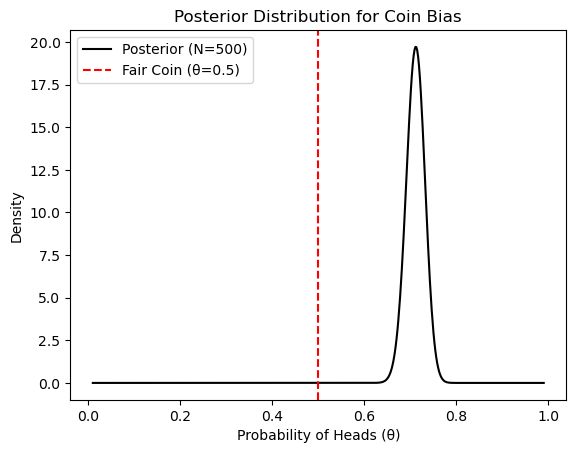

In [ ]:
# Plot the distribution
plt.plot(theta_vals, pdf_full, label = f'Posterior (N={len(data)})', color = 'black') # Distribution
plt.axvline(0.5, color = 'red', linestyle = '--', label = 'Fair Coin (θ=0.5)') # Expected fair coin probability
plt.title('Posterior Distribution for Coin Bias')
plt.xlabel('Probability of Heads (θ)')
plt.ylabel('Density')
plt.legend()
plt.show()

C.)  Test your code using different amounts of the data. Plot the distribution when 5, 50 and 500 coin
flips are used. Comment on what you find.

In [9]:
# Load data for 5, 50, and 500 flips
data5 = np.loadtxt("HW06_data.txt", max_rows = 5)
data50 = np.loadtxt("HW06_data.txt", max_rows = 50)
data500 = np.loadtxt("HW06_data.txt", max_rows = 500)

In [10]:
# Calculate distributions with each set of data. Assume Beta(1, 1)
pdf5, alpha5, beta5 = bayesian_inference(theta_vals, 1, 1, data5)
pdf50, alpha50, beta50 = bayesian_inference(theta_vals, 1, 1, data50)
pdf500, alpha500, beta500 = bayesian_inference(theta_vals, 1, 1, data500)

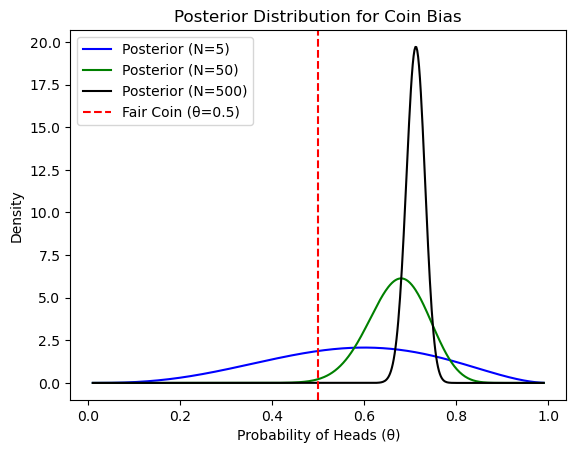

In [12]:
# Plot the distributions
plt.plot(theta_vals, pdf5, label = f'Posterior (N={len(data5)})', color = 'blue')
plt.plot(theta_vals, pdf50, label = f'Posterior (N={len(data50)})', color = 'green')
plt.plot(theta_vals, pdf500, label = f'Posterior (N={len(data500)})', color = 'black')
plt.axvline(0.5, color = 'red', linestyle = '--', label = 'Fair Coin (θ=0.5)') # Expected fair coin probability
plt.title('Posterior Distribution for Coin Bias')
plt.xlabel('Probability of Heads (θ)')
plt.ylabel('Density')
plt.legend()
plt.show()

D.) Repeat the previous part using different prior guesses. How does your prior distribution effect the
posterior distribution with different amounts of data?


In [21]:
# Repeat for N = 50 and N = 500 for different priors
pdf50_51, alpha50_51, beta50_51 = bayesian_inference(theta_vals, 5, 1, data50)
pdf500_51, alpha500_51, beta500_51 = bayesian_inference(theta_vals, 5, 1, data500)
pdf50_251, alpha50_251, beta50_251 = bayesian_inference(theta_vals, 25, 1, data50)
pdf500_251, alpha500_251, beta500_251 = bayesian_inference(theta_vals, 25, 1, data500)
pdf50_110, alpha50_110, beta50_110 = bayesian_inference(theta_vals, 1, 10, data50)
pdf500_110, alpha500_110, beta500_110 = bayesian_inference(theta_vals, 1, 10, data500)
pdf50_175, alpha50_175, beta50_175 = bayesian_inference(theta_vals, 1, 75, data50)
pdf500_175, alpha500_175, beta500_175 = bayesian_inference(theta_vals, 1, 75, data500)

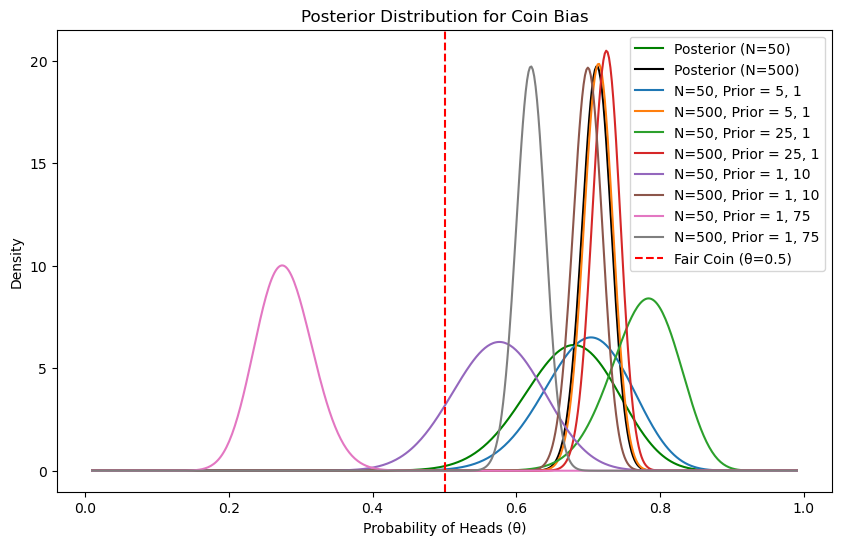

In [22]:
# Plot different distributions
plt.figure(figsize = (10, 6))
plt.plot(theta_vals, pdf50, label = f'Posterior (N={len(data50)})', color = 'green') # Original prior
plt.plot(theta_vals, pdf500, label = f'Posterior (N={len(data500)})', color = 'black') # Original prior
plt.plot(theta_vals, pdf50_51, label = f'N={len(data50)}, Prior = 5, 1')
plt.plot(theta_vals, pdf500_51, label = f'N={len(data500)}, Prior = 5, 1')
plt.plot(theta_vals, pdf50_251, label = f'N={len(data50)}, Prior = 25, 1')
plt.plot(theta_vals, pdf500_251, label = f'N={len(data500)}, Prior = 25, 1')
plt.plot(theta_vals, pdf50_110, label = f'N={len(data50)}, Prior = 1, 10')
plt.plot(theta_vals, pdf500_110, label = f'N={len(data500)}, Prior = 1, 10')
plt.plot(theta_vals, pdf50_175, label = f'N={len(data50)}, Prior = 1, 75')
plt.plot(theta_vals, pdf500_175, label = f'N={len(data500)}, Prior = 1, 75')
plt.axvline(0.5, color = 'red', linestyle = '--', label = 'Fair Coin (θ=0.5)') # Expected fair coin probability
plt.title('Posterior Distribution for Coin Bias')
plt.xlabel('Probability of Heads (θ)')
plt.ylabel('Density')
plt.legend()
plt.show()

# 3. MORE IN DEPTH

In this next section, we will calculate $\pi$ using the knowledge that $\pi = \frac{A}{r^2}$

A.) Create a random distribution of 100 points in a square of 1 × 1. Find how many of these fall in a
quarter of a radius 1 circle (see Figure 1). This is your data.

In [26]:
# Create random x and y arrays within [0, 1]
x_arr = np.random.rand(100)
y_arr = np.random.rand(100)
in_x = np.array([]) # Inside the quarter circle
in_y = np.array([])
out_x = np.array([]) # Outside the quarter circle
out_y = np.array([])
for i in range(len(x_arr)):
    if x_arr[i]**2 + y_arr[i]**2 <= 1: # Inside the quarter circle
        in_x = np.append(in_x, x_arr[i])
        in_y = np.append(in_y, y_arr[i])
    else:                               # Outside the quarter circle
        out_x = np.append(out_x, x_arr[i])
        out_y = np.append(out_y, y_arr[i])

(np.float64(-0.04999999999999993),
 np.float64(1.05),
 np.float64(-0.05),
 np.float64(1.05))

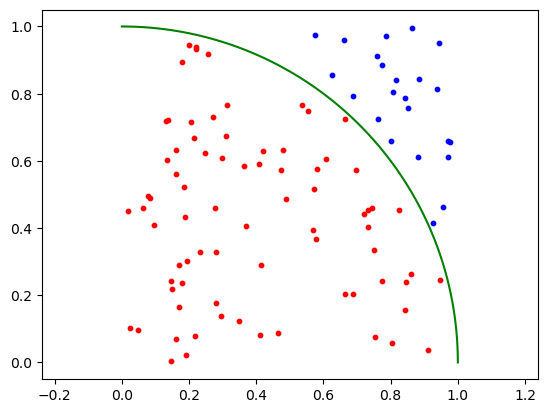

In [29]:
# Plot quarter circle line and the points inside and outside of the circle
theta = np.linspace(0, np.pi/2, 100) # For quarter circle
radius = 1
x = radius * np.cos(theta)
y = radius * np.sin(theta)

plt.plot(x, y, "g")
plt.scatter(in_x, in_y, color = "red", s = 10)
plt.scatter(out_x, out_y, color = "blue", s = 10)
plt.axis("Equal")

B.) Using Bayesian inference, find the probability of a point falling inside of the circle. From this
information and $\pi = \frac{A}{r^2}$, calculate an estimate for $\pi$

C.) Test how the relative error is affected by the prior and the number of data points used. Comment
on what you find.